## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Food Recommendation System</p>

<a id="toc"></a>

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Content</p>

* [INTRODUCTION](#0)
* [IMPORTING MODULES, LOADING DATA & DATA REVIEW](#1)
* [PREPROCESSING](#2)
* [EXPLORATORY DATA ANALYSIS (EDA)](#3)    
* [SCALING, CATEGORICAL VARIABLES, SPLITTING](#4)
* [MODELS](#5)
* [CONCLUSION](#6)

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Introduction</p>

<a id="0"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true"
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 1.1 Information About the Project

**Objective:**  
The primary objective of this project is to develop a recommendation system for a large food company to mitigate customer information overload. Since the dataset contains no explicit ratings, the core challenge is to build, compare, and evaluate multiple recommendation approaches by deriving implicit customer preferences from their transactional behavior.

**Scope:**  
This project goes beyond simply writing code; it focuses on thinking like a data scientist by making strategic decisions, evaluating trade-offs, and justifying choices with evidence. The scope encompasses:

* Exploring and preprocessing real-world, sparse data.

* Engineering an implicit rating strategy based on factors like frequency, spending, or recency.

* Implementing and comparing at least two different recommendation approaches (e.g., User-Based Collaborative Filtering, Item-Based Collaborative Filtering, Popularity Baseline).

* Evaluating methods using ranking metrics like Precision and Recall rather than traditional error metrics.

* Connecting the technical results to business value through deployment recommendations and addressing business constraints.

## 1.2 Description of the Dataset

- **Source:** The dataset (recom.csv) is a real transactional dataset provided by a large food company.

- **Size:** It contains approximately 50,000 transactions from 28,514 unique customers across 152 unique items.

- **Type:** This is tabular transactional data containing implicit feedback, collected over a 3-month period (August 26 to December 3, 2022). It is characterized by extreme sparsity (the median customer has only 1 transaction) and a high variance in item popularity.

## 1.3 Description of the Columns

- **Target Variable:** There is NO explicit target variable (like stars or numerical scores) in this dataset. Instead, an implicit rating is engineered using the behavioral signals provided in the data, such as purchase frequency, recency, spending, or simple binary purchase signals.

- **Feature Variables:** 

    * Main ID: The customer identifier (representing 28,514 unique customers)

    * Transaction ID: The unique identifier for each transaction.

    * Date: The transaction timestamp (August 26 - December 3, 2022).

    * Price: The price of the purchased item, ranging from $0.50 to $2,525.50.

    * Code Product: The product code, which represents 333 unique products.

    * Amount: The quantity of items purchased in the transaction, ranging from 1 to 54 units.

    * ItemKey: The item identifier for 152 unique items. Note: 43% of these values are missing and will require a strategic handling decision.


## <p style="background-color:#9d4f8c; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Importing Modules, Load Data & Data Review</p>

<a id="1"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

In [ ]:
import random
import warnings
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [14]:
# load the data
df = pd.read_csv('recom.csv')

df.head().T

,0,1,2,3,4
Unnamed: 0,0,1,2,3,4
Main_ID,90fada91,9006f9ac,32270891,97e03e47,41949228
Transaction_ID,264f7a69,45c7d853,61ad76dd,41ee09f6,244fe6d8
Date,2022-10-07 20:53:49.153,2022-09-17 15:54:57.187,2022-11-28 13:51:55.667,2022-09-12 16:20:22.110,2022-10-14 18:53:43.933
Price,125.0,19.0,141.0,4.5,129.5
Code_Product,5002.0,35012.0,5005.0,35078.5,49291.5
Amount,1.0,1.0,1.0,1.0,5.0
ItemKey,5002.0,NaN,5005.0,NaN,NaN


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      50000 non-null  int64  
 1   Main_ID         50000 non-null  str    
 2   Transaction_ID  50000 non-null  str    
 3   Date            50000 non-null  str    
 4   Price           50000 non-null  float64
 5   Code_Product    50000 non-null  float64
 6   Amount          50000 non-null  float64
 7   ItemKey         28597 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 3.1 MB


In [16]:
df.nunique()

Unnamed: 0        50000
Main_ID           28514
Transaction_ID    48403
Date              48398
Price               795
Code_Product        333
Amount               22
ItemKey             152
dtype: int64

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50000.0,24999.500000,14433.901067,0.0,12499.75,24999.5,37499.25,49999.0
Price,50000.0,62.560670,68.269624,0.5,24.50,45.5,83.00,2525.5
Code_Product,50000.0,32379.293540,21697.500334,5000.5,10013.00,40009.5,49291.50,350027.5
Amount,50000.0,1.232640,0.749353,1.0,1.00,1.0,1.00,54.0
ItemKey,28597.0,20775.740952,16481.882853,5000.5,5011.50,10023.0,40028.50,57035.5


In [18]:
df.duplicated().sum()

np.int64(0)

### Key Questions and Answer

1. How many unique customers?

In [19]:
print('Main_ID:', df['Main_ID'].nunique())

Main_ID: 28514


2. How many unique items (ItemKey vs Code_Product)?

In [20]:
print('ItemKey:', df['ItemKey'].nunique())
print('Code_Product:', df['Code_Product'].nunique())

ItemKey: 152
Code_Product: 333


3. Distribution of purchases per customer?

count    28514.000000
mean         1.697517
std          2.182692
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         44.000000
Name: Transaction_ID, dtype: float64

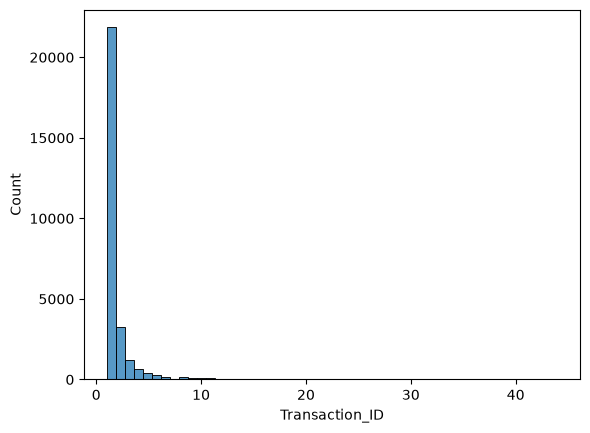

In [21]:
purchases_per_customer = df.groupby('Main_ID')['Transaction_ID'].nunique()

sns.histplot(purchases_per_customer, bins=50)

purchases_per_customer.describe()

4. Distribution of purchases per item?

count     152.000000
mean      187.447368
std       455.026363
min         1.000000
25%         7.750000
50%        33.500000
75%       156.250000
max      3781.000000
Name: Transaction_ID, dtype: float64

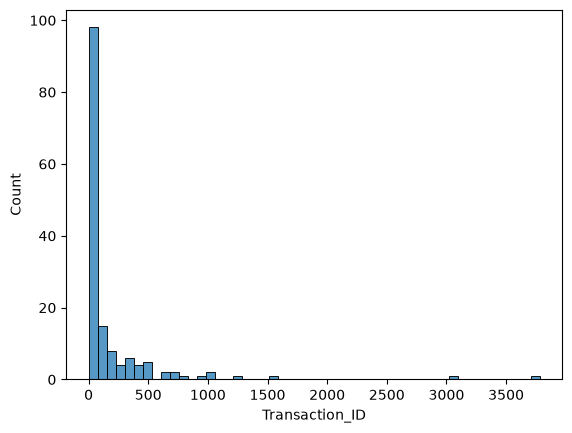

In [22]:
purchases_per_item = df.groupby('ItemKey')['Transaction_ID'].nunique()

sns.histplot(purchases_per_item, bins=50)

purchases_per_item.describe()

5. How many missing ItemKey values?

In [23]:
df['ItemKey'].isnull().sum()

np.int64(21403)

6. Date range and temporal patterns?

C:\Users\Mark\AppData\Local\Temp\ipykernel_20000\2869963844.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day_of_week', order=day_order, ax=axes[1], palette='flare')


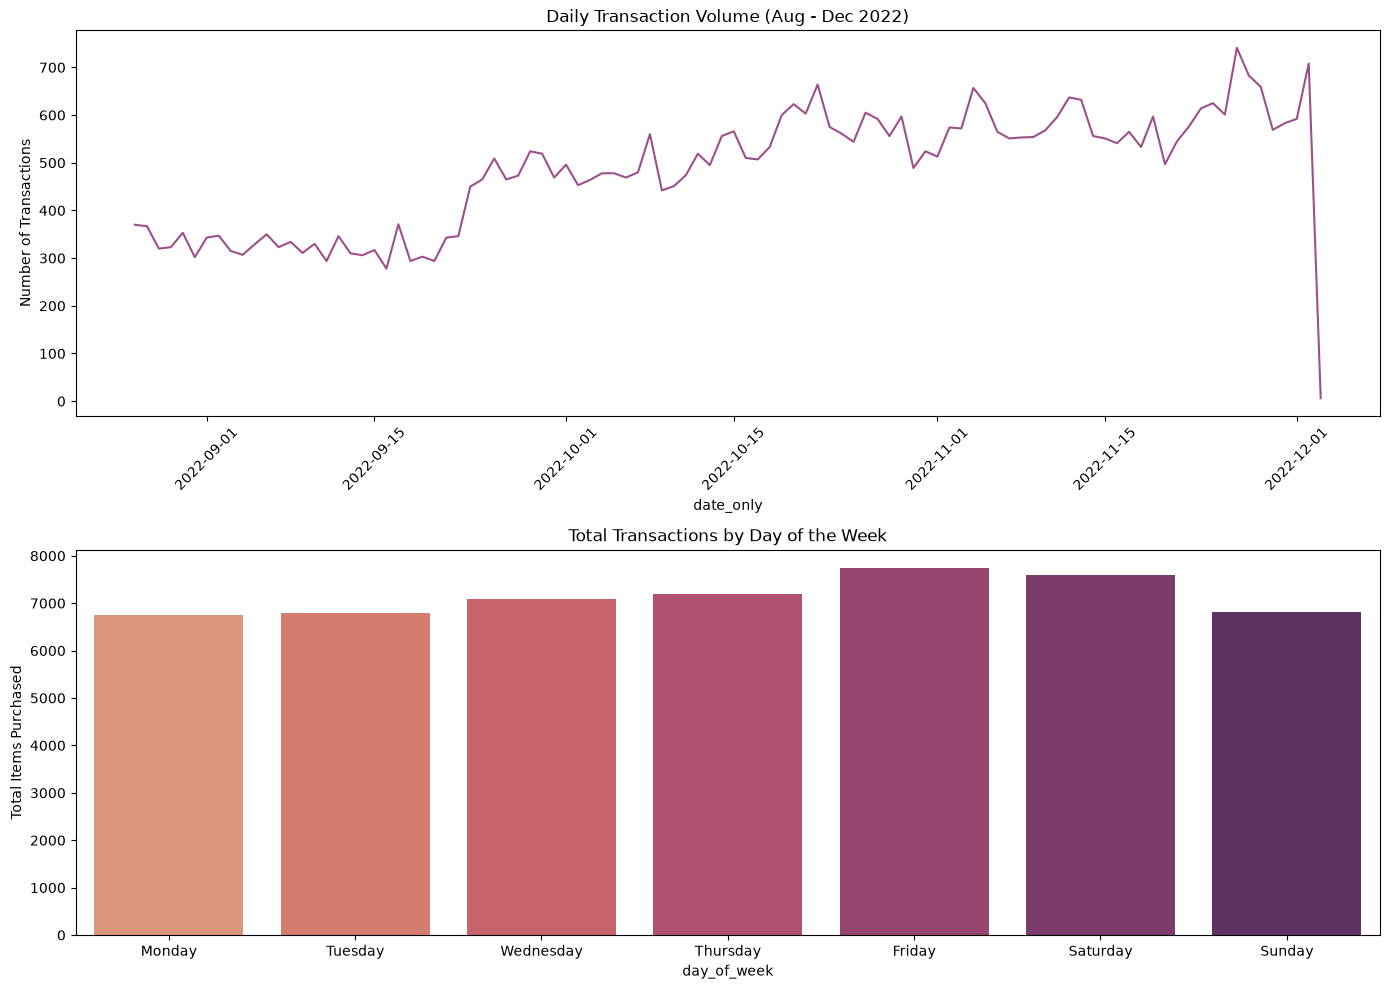

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

df['day_of_week'] = df['Date'].dt.day_name()
df['month'] = df['Date'].dt.month_name()
df['date_only'] = df['Date'].dt.date 

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily Transaction Volume 
daily_volume = df.groupby('date_only')['Transaction_ID'].nunique()
sns.lineplot(x=daily_volume.index, y=daily_volume.values, ax=axes[0], color='#9d4f8c')
axes[0].set_title('Daily Transaction Volume (Aug - Dec 2022)')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Transactions by Day of the Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='day_of_week', order=day_order, ax=axes[1], palette='flare')
axes[1].set_title('Total Transactions by Day of the Week')
axes[1].set_ylabel('Total Items Purchased')

plt.tight_layout()
plt.show()

### Standardize Column Names

In [61]:
df.columns

Index(['Unnamed: 0', 'Main_ID', 'Transaction_ID', 'Date', 'Price',
       'Code_Product', 'Amount', 'ItemKey'],
      dtype='str')

In [62]:
df.columns = (
    df.columns
    # Handle CamelCase (turns 'ItemKey' into 'Item_Key')
    .str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True) 
    
    # Replace spaces, colons, or any other non-alphanumeric character with an underscore
    .str.replace(r'[^a-zA-Z0-9]', '_', regex=True) 
    
    # Clean up any accidental double underscores (like from 'Unnamed: 0')
    .str.replace(r'_+', '_', regex=True)
    
    # Make everything lowercase
    .str.lower()
    
    # Strip any trailing or leading underscores just to be safe
    .str.strip('_') 

    # Rename 
    .str.replace(r'^code_product$', 'product_code', regex=True)
)

df.columns

Index(['unnamed_0', 'main_id', 'transaction_id', 'date', 'price',
       'product_code', 'amount', 'item_key'],
      dtype='str')

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Preprocessing</p>

<a id="2"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 2.1 Data Cleaning


### unnamed_0

In [63]:
df.drop(columns='unnamed_0', inplace=True)

### main_id

In [64]:
df['main_id'].value_counts(dropna=False)

main_id
751131ee    51
734264e5    47
d0778daf    39
6b00f3c8    36
aa6d52d8    36
            ..
50fef10a     1
db8a4949     1
2316a392     1
a8bc484a     1
8821da12     1
Name: count, Length: 28514, dtype: int64

### transaction id

In [65]:
df['transaction_id'].value_counts(dropna=False)

transaction_id
f56648eb    3
fe768cee    3
915a9d85    3
8eba900b    3
056168dd    3
           ..
4e0eb5ab    1
c9946c16    1
d1a35c5c    1
66f9b474    1
0ff8b41f    1
Name: count, Length: 48403, dtype: int64

### date

In [66]:
df['date'].value_counts(dropna=False)

date
2022-12-01 16:31:22.523    3
2022-10-04 20:53:56.160    3
2022-11-26 15:11:45.997    3
2022-10-18 17:56:53.440    3
2022-11-23 17:04:44.123    3
                          ..
2022-09-24 21:48:20.847    1
2022-11-18 19:49:01.973    1
2022-11-24 20:02:43.023    1
2022-11-06 13:07:01.423    1
2022-10-10 16:06:20.473    1
Name: count, Length: 48398, dtype: int64

### price

In [68]:
df['price'].value_counts(dropna=False)

price
7.5      938
7.0      516
30.0     468
30.5     445
34.5     421
        ... 
567.5      1
889.5      1
457.5      1
682.5      1
269.0      1
Name: count, Length: 795, dtype: int64

### product code 

In [69]:
df['product_code'].value_counts(dropna=False)

product_code
49292.0    4862
49291.5    4694
5000.5     3814
45004.0    3071
10013.0    1572
           ... 
60051.0       1
35072.0       1
20034.0       1
48590.0       1
35008.0       1
Name: count, Length: 333, dtype: int64

### amount

In [70]:
df['amount'].value_counts(dropna=False)

amount
1.0     41695
2.0      6369
3.0      1279
4.0       415
5.0       130
6.0        56
7.0        16
10.0       11
8.0         7
20.0        4
13.0        4
18.0        3
9.0         2
16.0        1
14.0        1
41.0        1
28.0        1
17.0        1
54.0        1
19.0        1
33.0        1
12.0        1
Name: count, dtype: int64

### item key

In [71]:
df['item_key'].value_counts(dropna=False)

item_key
NaN        21403
5000.5      3814
45004.0     3071
10013.0     1572
5009.0      1242
           ...  
30001.5        1
25005.5        1
57035.5        1
40065.0        1
20034.0        1
Name: count, Length: 153, dtype: int64

## 2.2 Missing Value Analysis

In [72]:
df.isnull().sum()

main_id               0
transaction_id        0
date                  0
price                 0
product_code          0
amount                0
item_key          21403
dtype: int64

### item key

This feature is dropped and product code is used in its place.

In [ ]:
df.drop(columns='item_key', inplace=True)

## 2.3 Outlier Analysis

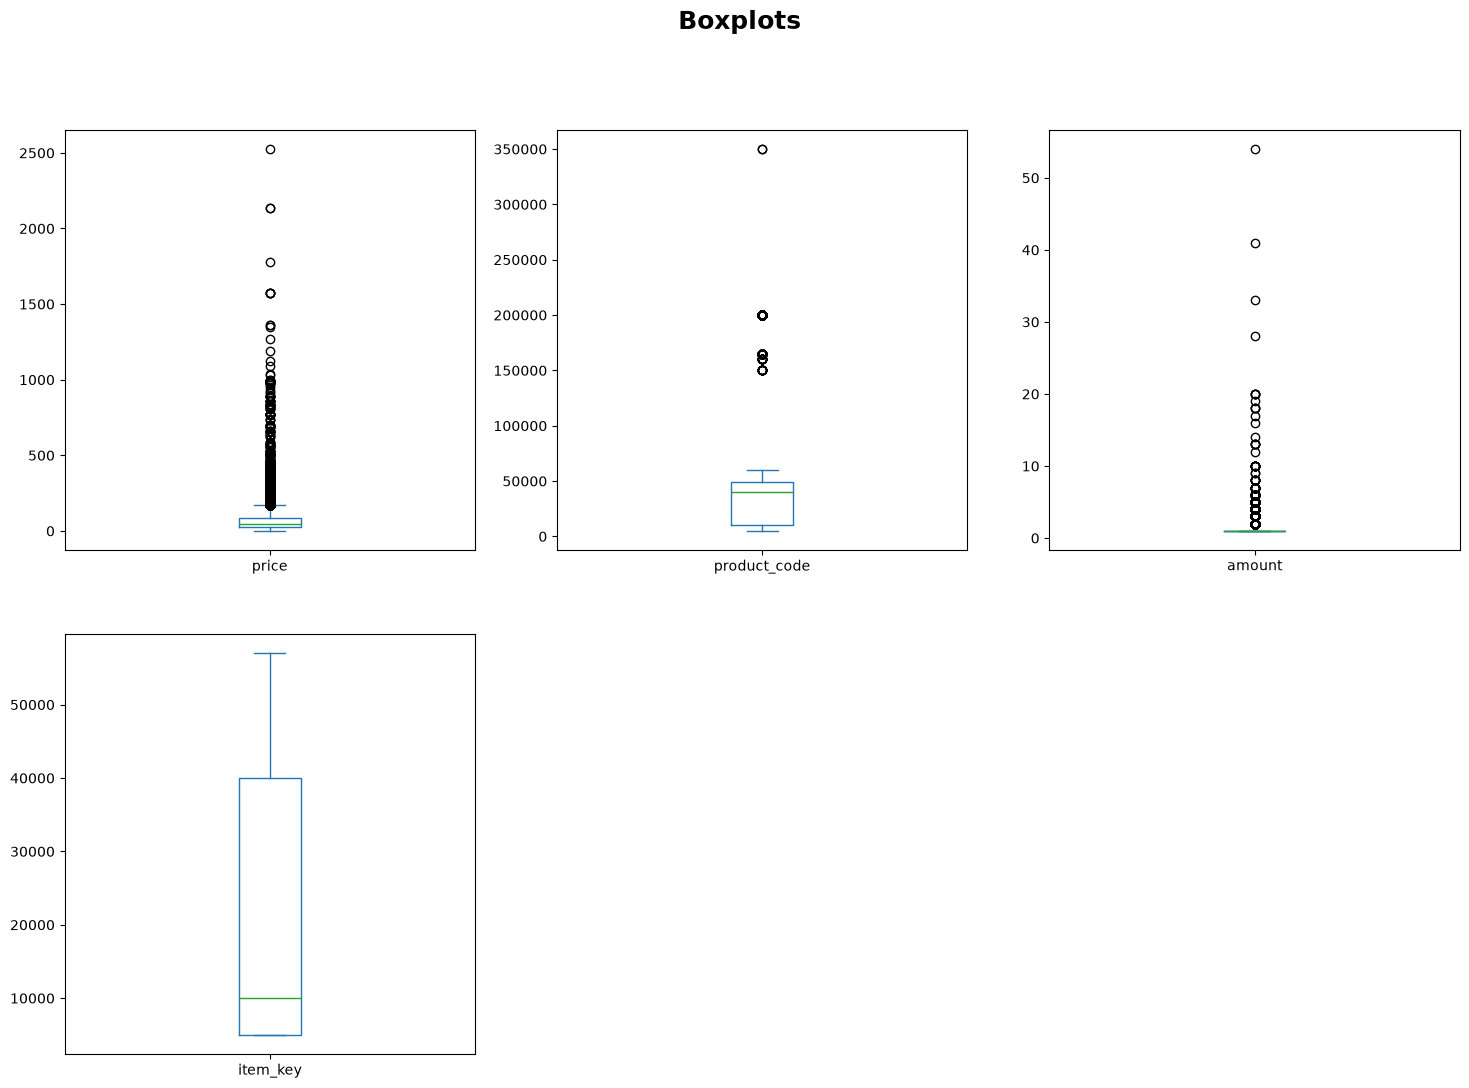

In [74]:
df.plot(kind="box", subplots=True, figsize=(18, 12), layout=(2, 3))
plt.suptitle("Boxplots", fontsize=18, fontweight="bold")
plt.show()

No way to check legitimate outliers with only product code and item key.

## 2.4 Feature Engineering

### Customer Preference

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">Exploratory Data Analysis (EDA)</p>

<a id="3"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 3.1 Data Visualization
Visualize the data to identify trends, patterns, or anomalies. Suggested visualizations:

## 3.2 Correlation Analysis
Analyze correlations between numerical features

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">4. Scaling, Categorical Variables, and Splitting</p>

<a id="4"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>


## 4.1 Encoding Categorical Variables
Handle categorical features:

- **Label Encoding:** For ordinal variables.
- **One-Hot Encoding:** For nominal variables.

## 4.2 Splitting
Split the data into training and testing sets to avoid data leakage:

- **Train/Test Split:** Usually a 70/30 or 80/20 split.
- **Stratified Sampling:** If the dataset is imbalanced, ensure stratified sampling of the target variable.

## 4.3 Scaling
Normalize or standardize features to improve model performance, especially for distance-based algorithms (e.g., k-NN, SVM):

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">5. Models</p>

<a id="5"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## 5.1 Creating Models and Fine-Tuning
Build and evaluate baseline models using different machine learning algorithms. Improve model performance by tuning hyperparameters:

### 5.1.1 Logistic Regression (Ex Model 1)

## 5.2 Model Comparisons
Compare the performance of different models.

## 5.3 Feature Importance
Analyze and explain the most important features:

## 5.4 Final Model
Choose the best-performing model based on your evaluations and fine-tuning.

## 5.5 Create a Model with Fewer Features (if necessary)

## 5.6 Pickle the Model
Save the final model for future deployment:

## <p style="background-color:#fea162; font-family:newtimeroman; color:#FFF9ED; font-size:175%; text-align:center; border-radius:10px 10px;">6. Conclusion</p>

<a id="6"></a>
<a href="#toc" class="btn btn-primary btn-sm" role="button" aria-pressed="true" 
style="color:blue; background-color:#dfa8e4" data-toggle="popover">Content</a>

## Decision Log
For each consider:
1. What decision needed to be made?
2. What options did you consider?
3. What criteria did you use to evaluate options?
4. What did you choose and WHY?
5. What are the trade-offs of your choice?
6. What evidence supports your decision?

### Handling missing item key: 

* Fill NA with product code

    * Pros: Simple and retain 100% of transaction history

    * Cons: If product code shares the same ID (e.g., "12" means "apple" in item key but "bread" in code product), the recommendation algorithm will combine them

* Concatenate with product code

    * Pros: Avoids ID collisions

    * Cons: Worsen the sparsity

* **Drop and replace with product code** 

    * Pros: Simple and retain 100% of transaction history

    * Cons: Removes any way to identify specific items

### Similarity Metric

### Implicit Rating